# Exploratory Data Analysis — Flight Data 2024

**Goal:** Understand the raw data before writing any pipeline code.

**Sections:**
1. Load Data
2. Basic Info
3. Missing Value Analysis
4. Target Variable Analysis
5. Distribution Plots
6. Delay by Category (carrier, time, day, route)
7. Correlation Analysis
8. Key Findings & Feature Ideas

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/raw/flight_data_2024.csv', low_memory=False)
print(f'Rows:    {len(df):,}')
print(f'Columns: {len(df.columns)}')

Rows:    7,079,081
Columns: 35


## 2. Basic Info

In [2]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,7079081.0,2024.000000,0.000000,2024.0,2024.0,2024.0,2024.0,2024.0
month,7079081.0,6.584868,3.396806,1.0,4.0,7.0,10.0,12.0
day_of_month,7079081.0,15.784451,8.786433,1.0,8.0,16.0,23.0,31.0
day_of_week,7079081.0,3.981945,2.012279,1.0,2.0,4.0,6.0,7.0
op_carrier_fl_num,7079080.0,2504.622501,1652.252505,1.0,1151.0,2227.0,3717.0,8819.0
crs_dep_time,7079081.0,1327.299824,493.030621,1.0,905.0,1320.0,1736.0,2400.0
dep_time,6986422.0,1330.765191,509.477907,1.0,908.0,1325.0,1746.0,2400.0
dep_delay,6986111.0,12.677082,56.059970,-96.0,-6.0,-2.0,9.0,3777.0
taxi_out,6983347.0,17.904450,9.677410,1.0,12.0,15.0,21.0,214.0
wheels_off,6983347.0,1353.541910,512.047456,1.0,924.0,1338.0,1801.0,2400.0


In [5]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')

fl_date: 366 unique values
op_unique_carrier: 15 unique values
origin: 348 unique values
origin_city_name: 342 unique values
origin_state_nm: 52 unique values
dest: 348 unique values
dest_city_name: 342 unique values
dest_state_nm: 52 unique values
cancellation_code: 4 unique values


## 3. Missing Value Analysis

In [6]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

print('Columns with missing values:\n')
for col, pct in null_pct.items():
    bar = '█' * int(pct / 2)
    print(f'{col:<30} {pct:>6.2f}%  {bar}')

Columns with missing values:

cancellation_code               98.64%  █████████████████████████████████████████████████
arr_delay                        1.61%  
actual_elapsed_time              1.61%  
air_time                         1.61%  
wheels_on                        1.38%  
taxi_in                          1.38%  
arr_time                         1.38%  
taxi_out                         1.35%  
wheels_off                       1.35%  
dep_time                         1.31%  
dep_delay                        1.31%  


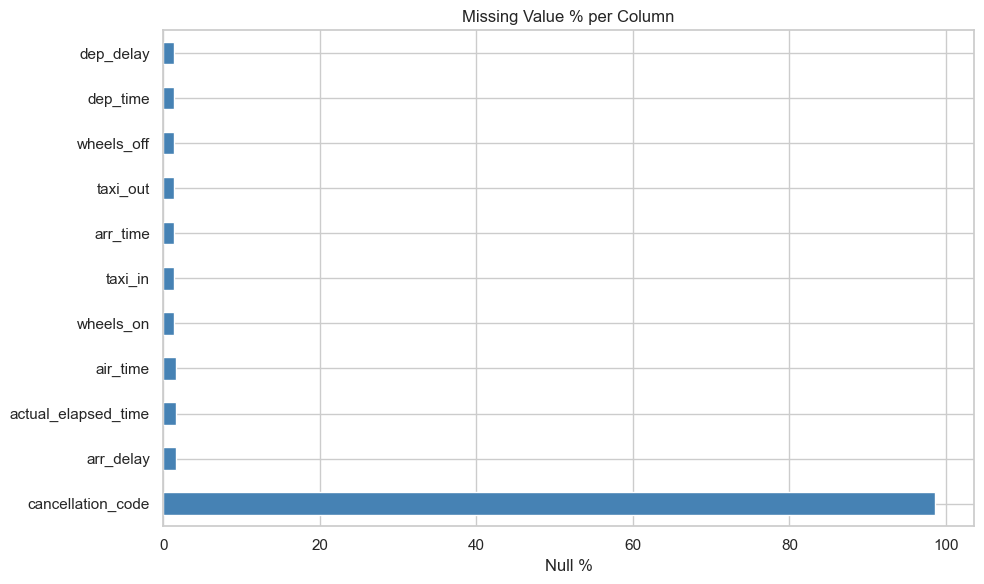

In [7]:
plt.figure(figsize=(10, 6))
null_pct.plot(kind='barh', color='steelblue')
plt.xlabel('Null %')
plt.title('Missing Value % per Column')
plt.tight_layout()
plt.show()

## 4. Target Variable Analysis

Our prediction target is `arr_delay` — arrival delay in minutes.

We will create a binary target `is_delayed` using the FAA standard: a flight is delayed if it arrives **more than 15 minutes late**.

In [8]:
df_active = df[df['cancelled'] == 0].copy()
print(f'Total flights:     {len(df):,}')
print(f'Cancelled flights: {df["cancelled"].sum():,} ({df["cancelled"].mean():.1%})')
print(f'Active flights:    {len(df_active):,}')

Total flights:     7,079,081
Cancelled flights: 96,315 (1.4%)
Active flights:    6,982,766


In [9]:
df_active['is_delayed'] = (df_active['arr_delay'] > 15).astype(int)

delay_rate = df_active['is_delayed'].mean()
print(f'Delayed flights: {df_active["is_delayed"].sum():,} ({delay_rate:.1%})')
print(f'On-time flights: {(df_active["is_delayed"] == 0).sum():,} ({1 - delay_rate:.1%})')

Delayed flights: 1,403,388 (20.1%)
On-time flights: 5,579,378 (79.9%)


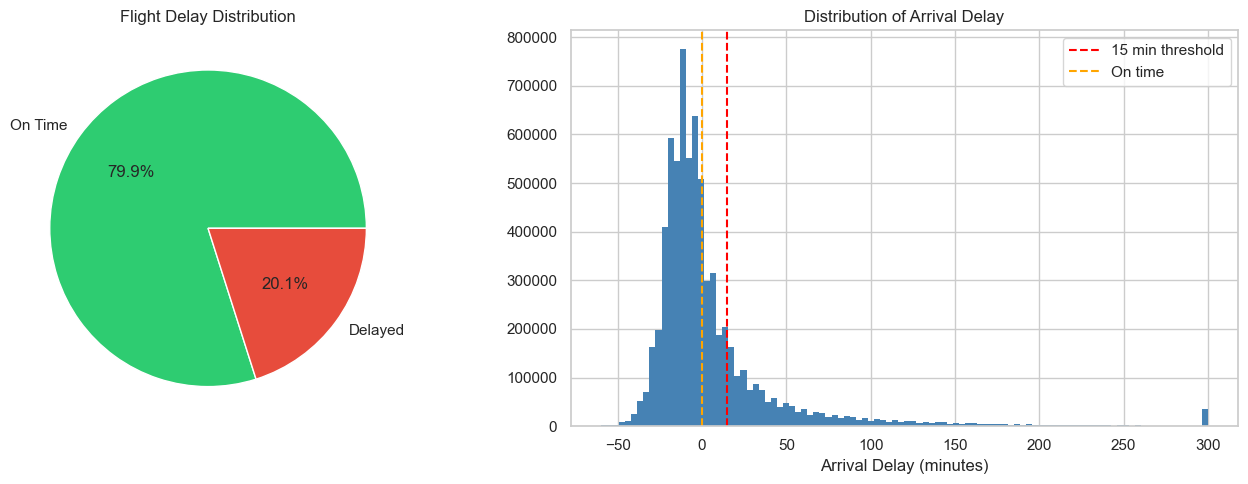

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    df_active['is_delayed'].value_counts(),
    labels=['On Time', 'Delayed'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Flight Delay Distribution')

clipped = df_active['arr_delay'].clip(-60, 300)
axes[1].hist(clipped, bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(15, color='red', linestyle='--', label='15 min threshold')
axes[1].axvline(0, color='orange', linestyle='--', label='On time')
axes[1].set_xlabel('Arrival Delay (minutes)')
axes[1].set_title('Distribution of Arrival Delay')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
print('Arrival delay statistics (minutes):')
print(df_active['arr_delay'].describe().round(1))
print(f'\nFlights that arrived EARLY: {(df_active["arr_delay"] < 0).mean():.1%}')

Arrival delay statistics (minutes):
count    6965267.0
mean           7.1
std           58.0
min         -126.0
25%          -15.0
50%           -6.0
75%            9.0
max         3803.0
Name: arr_delay, dtype: float64

Flights that arrived EARLY: 61.8%


## 5. Distribution Plots — Key Numerical Columns

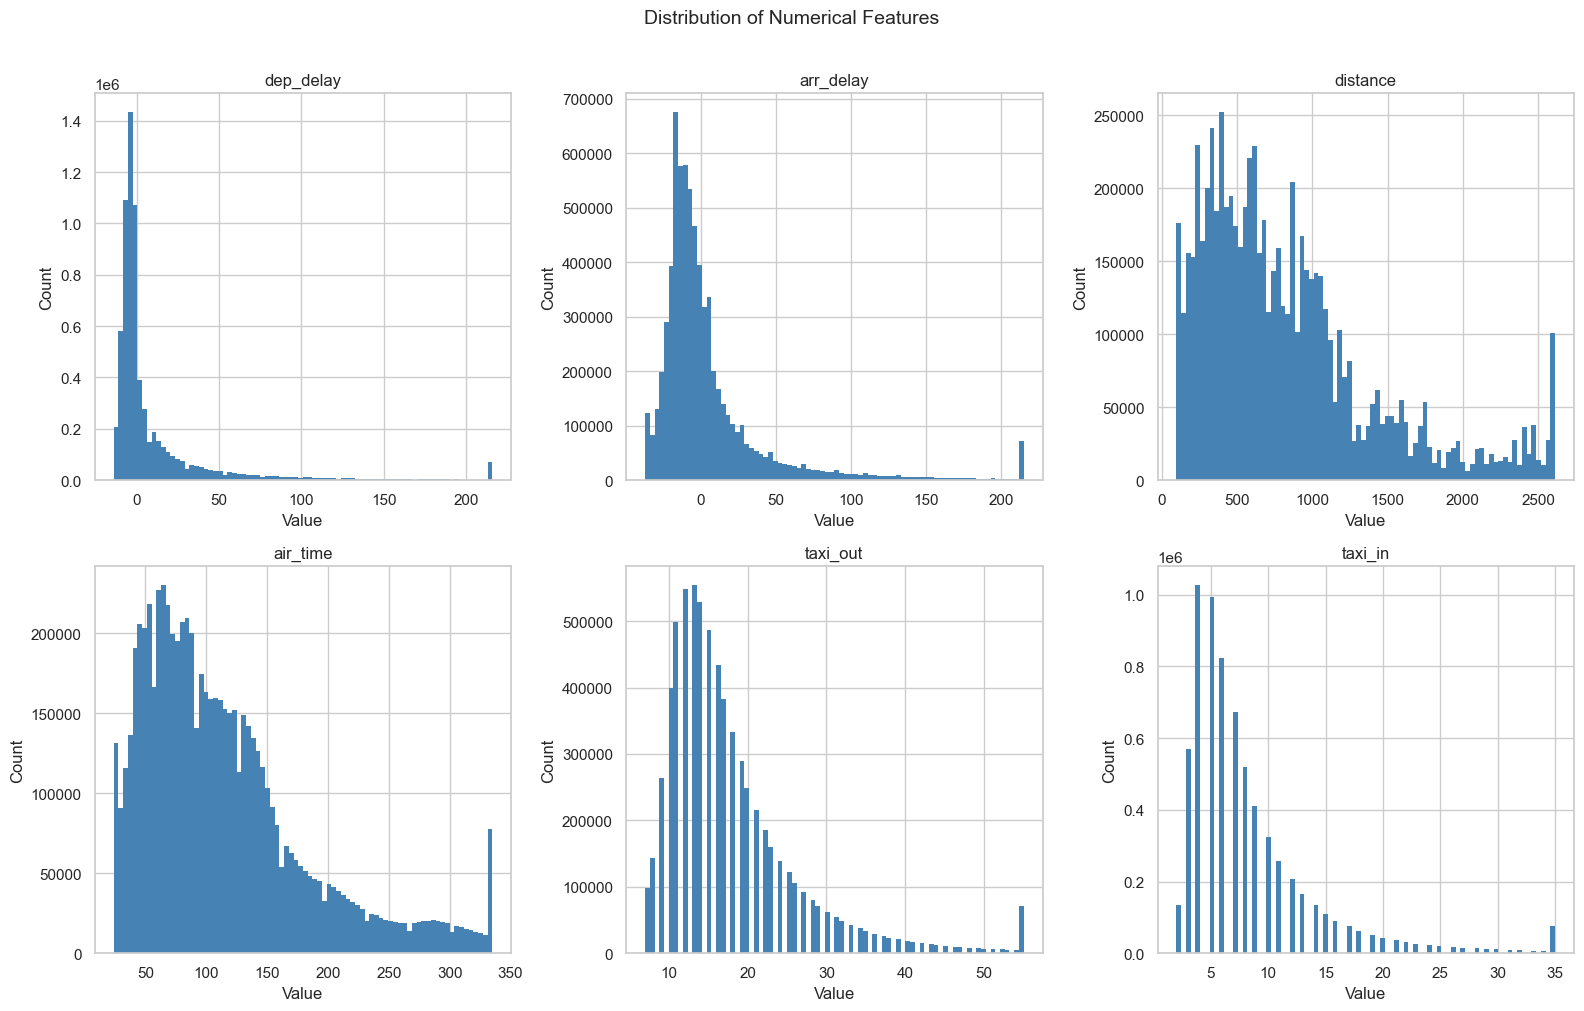

In [12]:
num_cols = ['dep_delay', 'arr_delay', 'distance', 'air_time', 'taxi_out', 'taxi_in']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_active[col].dropna().clip(
        df_active[col].quantile(0.01),
        df_active[col].quantile(0.99)
    )
    axes[i].hist(data, bins=80, color='steelblue', edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Delay by Category

Here we ask: **which factors are associated with higher delay rates?**

For hour, day, and month charts — the bar color is value-driven: **deep red = highest delay rate, deep blue = lowest**.

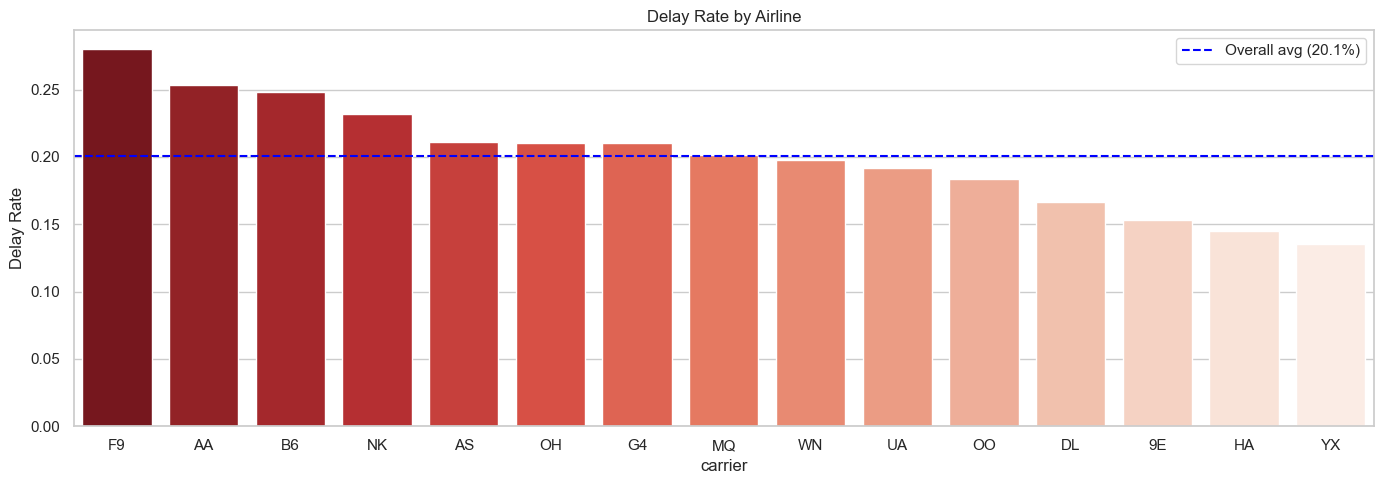

In [13]:
# Delay rate by airline
carrier_delay = (
    df_active.groupby('op_unique_carrier')['is_delayed']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
carrier_delay.columns = ['carrier', 'delay_rate']

plt.figure(figsize=(14, 5))
sns.barplot(data=carrier_delay, x='carrier', y='delay_rate', palette='Reds_r')
plt.axhline(delay_rate, color='blue', linestyle='--', label=f'Overall avg ({delay_rate:.1%})')
plt.ylabel('Delay Rate')
plt.title('Delay Rate by Airline')
plt.legend()
plt.tight_layout()
plt.show()

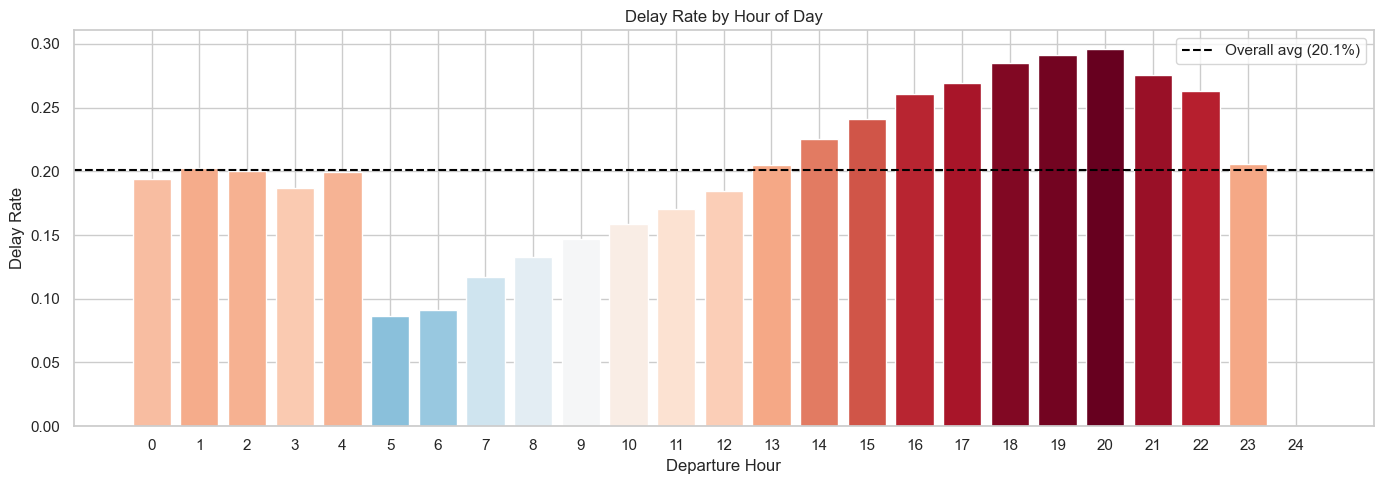

In [14]:
# Delay rate by hour of day
# crs_dep_time is stored as integer like 1430 meaning 14:30 — divide by 100 to get the hour
df_active['dep_hour'] = df_active['crs_dep_time'] // 100

hour_delay = (
    df_active.groupby('dep_hour')['is_delayed']
    .mean()
    .reset_index()
)

# Color each bar by its value — highest delay rate = deep red, lowest = deep blue
norm = mcolors.Normalize(vmin=hour_delay['is_delayed'].min(), vmax=hour_delay['is_delayed'].max())
colors = [cm.RdBu_r(norm(v)) for v in hour_delay['is_delayed']]

plt.figure(figsize=(14, 5))
plt.bar(hour_delay['dep_hour'], hour_delay['is_delayed'], color=colors)
plt.axhline(delay_rate, color='black', linestyle='--', label=f'Overall avg ({delay_rate:.1%})')
plt.xlabel('Departure Hour')
plt.ylabel('Delay Rate')
plt.title('Delay Rate by Hour of Day')
plt.xticks(hour_delay['dep_hour'])
plt.legend()
plt.tight_layout()
plt.show()

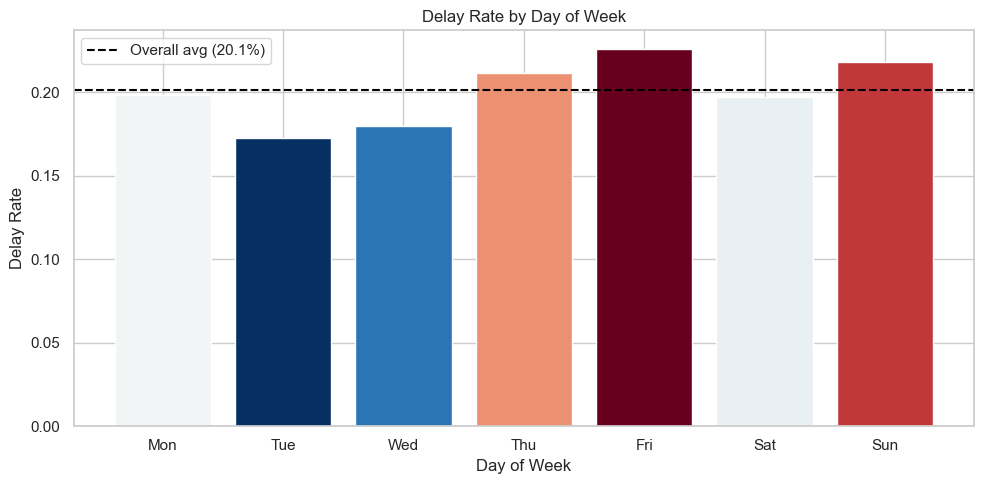

In [15]:
# Delay rate by day of week — 1=Monday, 7=Sunday
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_delay = (
    df_active.groupby('day_of_week')['is_delayed']
    .mean()
    .reset_index()
)
day_delay['day_name'] = day_delay['day_of_week'].map(day_names)

norm = mcolors.Normalize(vmin=day_delay['is_delayed'].min(), vmax=day_delay['is_delayed'].max())
colors = [cm.RdBu_r(norm(v)) for v in day_delay['is_delayed']]

plt.figure(figsize=(10, 5))
plt.bar(day_delay['day_name'], day_delay['is_delayed'], color=colors)
plt.axhline(delay_rate, color='black', linestyle='--', label=f'Overall avg ({delay_rate:.1%})')
plt.xlabel('Day of Week')
plt.ylabel('Delay Rate')
plt.title('Delay Rate by Day of Week')
plt.legend()
plt.tight_layout()
plt.show()

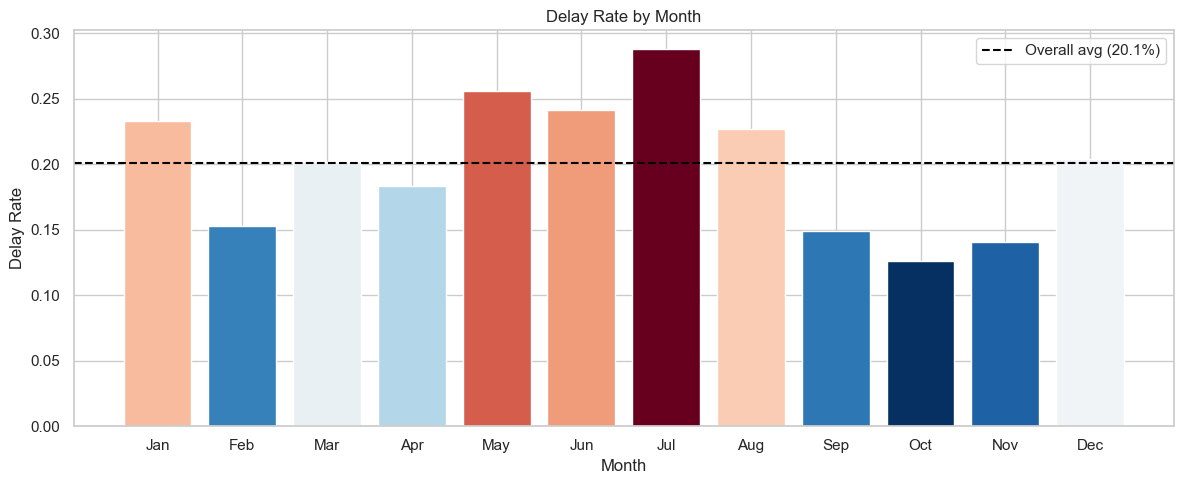

In [16]:
# Delay rate by month
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_delay = (
    df_active.groupby('month')['is_delayed']
    .mean()
    .reset_index()
)
month_delay['month_name'] = month_delay['month'].map(month_names)

norm = mcolors.Normalize(vmin=month_delay['is_delayed'].min(), vmax=month_delay['is_delayed'].max())
colors = [cm.RdBu_r(norm(v)) for v in month_delay['is_delayed']]

plt.figure(figsize=(12, 5))
plt.bar(month_delay['month_name'], month_delay['is_delayed'], color=colors)
plt.axhline(delay_rate, color='black', linestyle='--', label=f'Overall avg ({delay_rate:.1%})')
plt.xlabel('Month')
plt.ylabel('Delay Rate')
plt.title('Delay Rate by Month')
plt.legend()
plt.tight_layout()
plt.show()

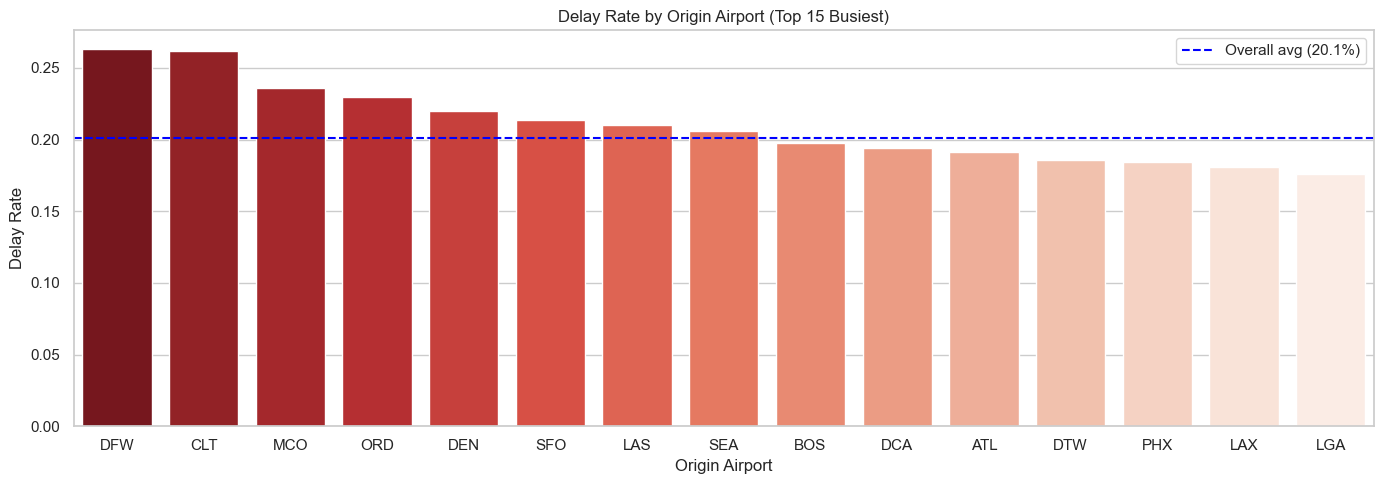

In [17]:
# Top 15 busiest origin airports and their delay rates
top_airports = df_active['origin'].value_counts().head(15).index
airport_delay = (
    df_active[df_active['origin'].isin(top_airports)]
    .groupby('origin')['is_delayed']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.barplot(data=airport_delay, x='origin', y='is_delayed', palette='Reds_r')
plt.axhline(delay_rate, color='blue', linestyle='--', label=f'Overall avg ({delay_rate:.1%})')
plt.xlabel('Origin Airport')
plt.ylabel('Delay Rate')
plt.title('Delay Rate by Origin Airport (Top 15 Busiest)')
plt.legend()
plt.tight_layout()
plt.show()

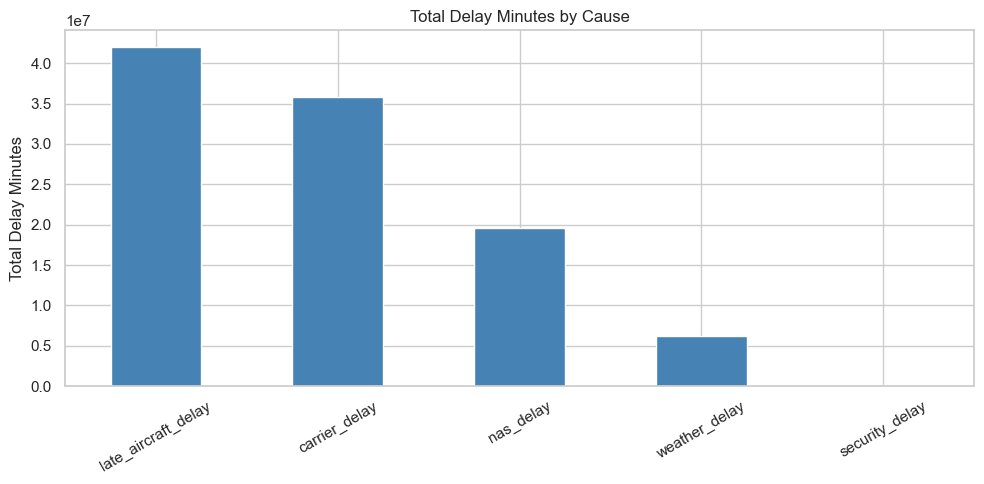


Delay cause breakdown (% of total delay minutes):
late_aircraft_delay    40.4
carrier_delay          34.5
nas_delay              18.9
weather_delay           6.0
security_delay          0.2


In [18]:
# Breakdown of delay causes
delay_causes = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
cause_totals = df_active[delay_causes].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
cause_totals.plot(kind='bar', color='steelblue')
plt.ylabel('Total Delay Minutes')
plt.title('Total Delay Minutes by Cause')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nDelay cause breakdown (% of total delay minutes):')
print((cause_totals / cause_totals.sum() * 100).round(1).to_string())

## 7. Correlation Analysis

Correlation measures how strongly two columns move together.
- **+1.0** = perfectly positively correlated
- **-1.0** = perfectly negatively correlated
- **0.0** = no relationship

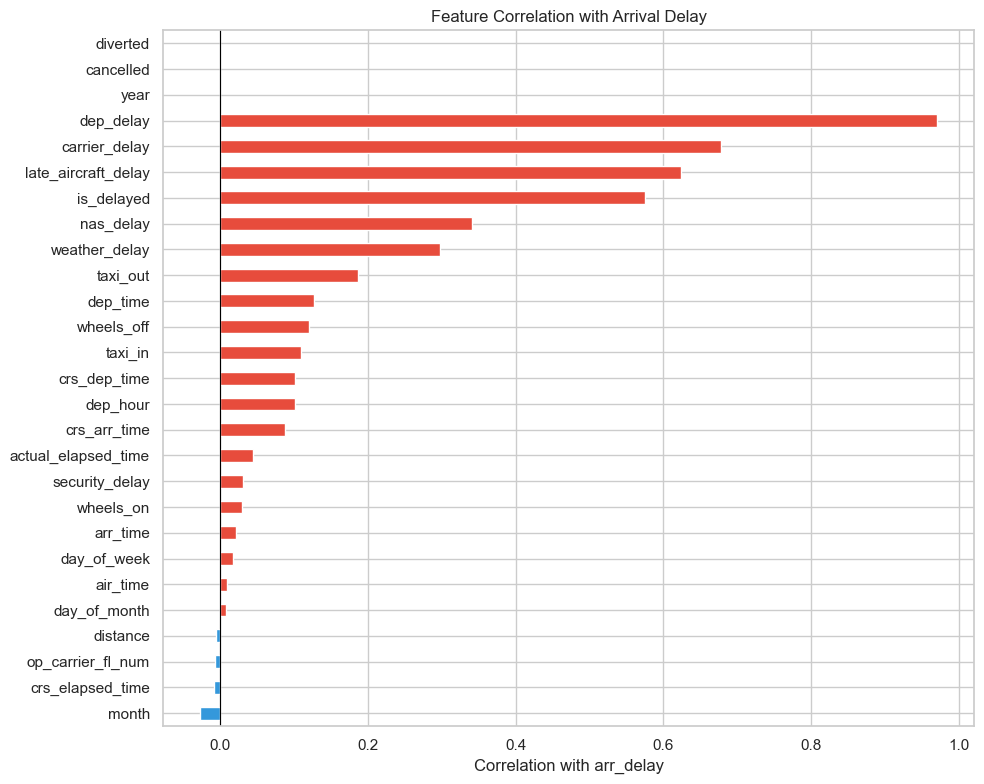

In [19]:
num_df = df_active.select_dtypes(include='number')
corr_with_target = num_df.corr()['arr_delay'].drop('arr_delay').sort_values()

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind='barh', color=['#e74c3c' if x > 0 else '#3498db' for x in corr_with_target])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with arr_delay')
plt.title('Feature Correlation with Arrival Delay')
plt.tight_layout()
plt.show()

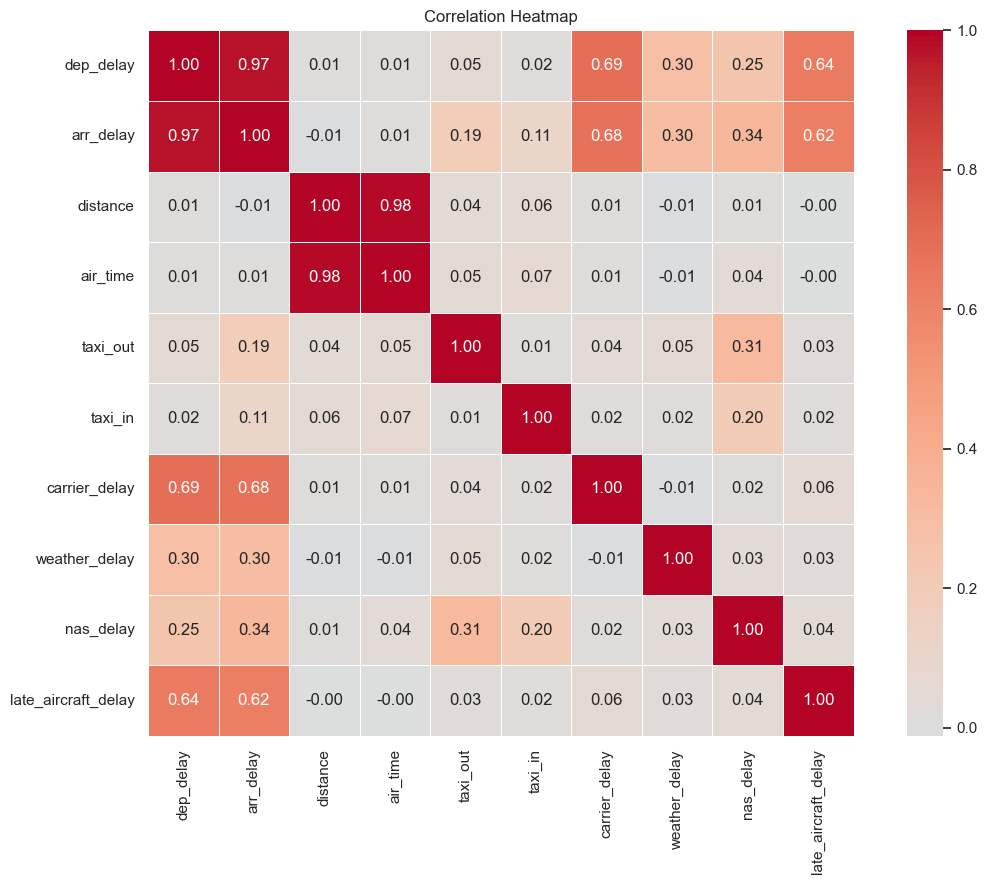

In [20]:
key_cols = ['dep_delay', 'arr_delay', 'distance', 'air_time',
            'taxi_out', 'taxi_in', 'carrier_delay', 'weather_delay',
            'nas_delay', 'late_aircraft_delay']

plt.figure(figsize=(12, 9))
sns.heatmap(
    df_active[key_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 8. Key Findings & Feature Ideas

In [21]:
print('=== KEY FINDINGS ===')
print(f'Dataset: {len(df):,} flights in 2024')
print(f'Cancellation rate: {df["cancelled"].mean():.2%}')
print(f'Overall delay rate (>15 min): {delay_rate:.2%}')
print()

print('Most delayed airline:')
print(f'  {carrier_delay.iloc[0]["carrier"]} — {carrier_delay.iloc[0]["delay_rate"]:.1%}')
print()

print('Most delayed hour of day:')
worst_hour = hour_delay.loc[hour_delay['is_delayed'].idxmax()]
print(f'  Hour {int(worst_hour["dep_hour"]):02d}:00 — {worst_hour["is_delayed"]:.1%}')
print()

print('Top delay cause (by total minutes):')
print(f'  {cause_totals.index[0]}: {cause_totals.iloc[0]:,.0f} minutes')
print()

print('Strongest correlates with arr_delay:')
print(corr_with_target.tail(5).to_string())

print()
print('=== FEATURE IDEAS FOR build_features.py ===')
print('  - dep_hour         : extract hour from crs_dep_time')
print('  - is_peak_hour     : 1 if dep_hour in [7,8,17,18,19]')
print('  - is_weekend       : 1 if day_of_week in [6, 7]')
print('  - is_holiday_month : 1 if month in [6,7,8,12]')
print('  - route            : origin + dest combined as single feature')
print('  - dep_hour_bin     : morning / afternoon / evening / night')

=== KEY FINDINGS ===
Dataset: 7,079,081 flights in 2024
Cancellation rate: 1.36%
Overall delay rate (>15 min): 20.10%

Most delayed airline:
  F9 — 28.0%

Most delayed hour of day:
  Hour 20:00 — 29.6%

Top delay cause (by total minutes):
  late_aircraft_delay: 41,974,007 minutes

Strongest correlates with arr_delay:
carrier_delay    0.677582
dep_delay        0.970694
year                  NaN
cancelled             NaN
diverted              NaN

=== FEATURE IDEAS FOR build_features.py ===
  - dep_hour         : extract hour from crs_dep_time
  - is_peak_hour     : 1 if dep_hour in [7,8,17,18,19]
  - is_weekend       : 1 if day_of_week in [6, 7]
  - is_holiday_month : 1 if month in [6,7,8,12]
  - route            : origin + dest combined as single feature
  - dep_hour_bin     : morning / afternoon / evening / night


Summary of decisions:

Decision	                                        Action
Drop year, op_carrier_fl_num	                    Add to drop_columns in config
Extract hours from scheduled times	                build_features.py
Remove cancelled flights	                        Already done in pipeline
Remove outliers from delay columns	                preprocessing.py IQR
Log transform skewed columns	                    build_features.py
Keep distance, drop air_time	                    Feature selection
Keep dep_delay, drop arr_delay from features	    arr_delay → is_delayed target
is_delayed as bool	                                build_features.py
